In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/healthcare.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.shape

(1338, 7)

In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

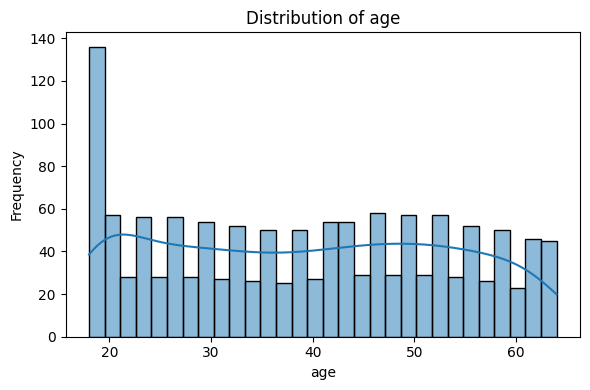

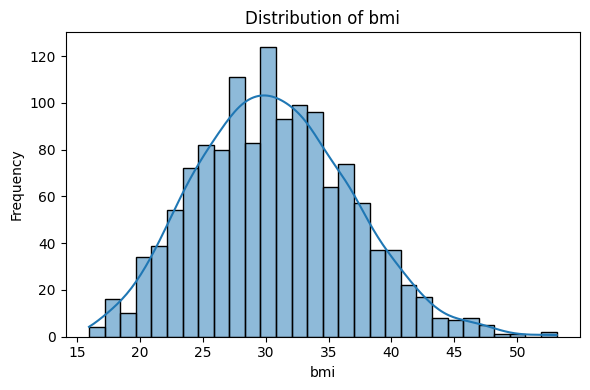

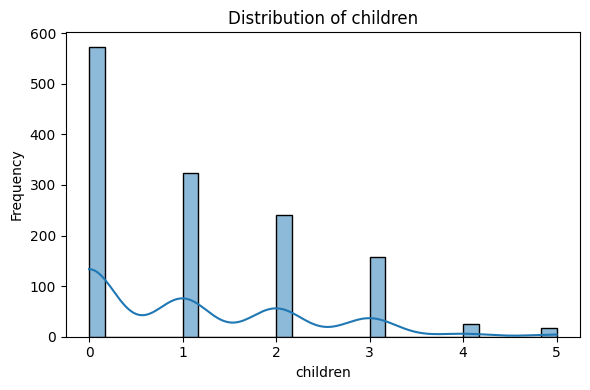

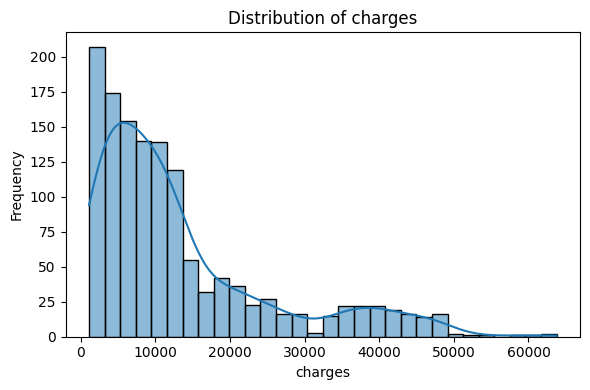

In [11]:
numerical_columns = ['age','bmi','children','charges']
for col in numerical_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde=True,bins=30)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

<Axes: xlabel='children', ylabel='count'>

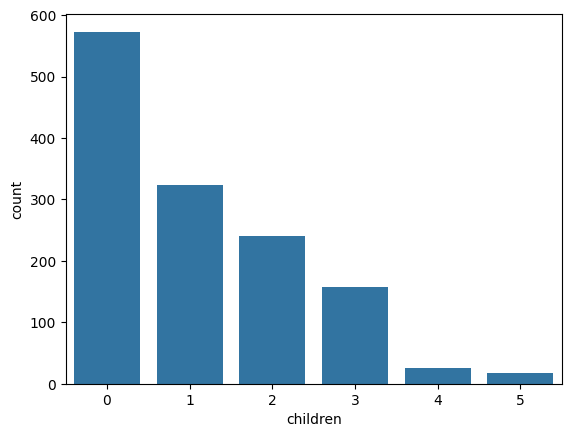

In [12]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

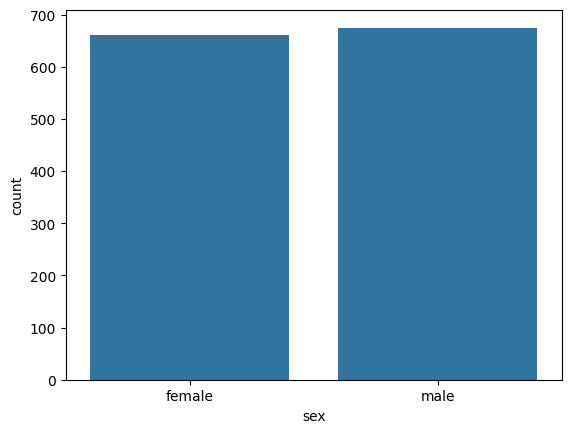

In [13]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

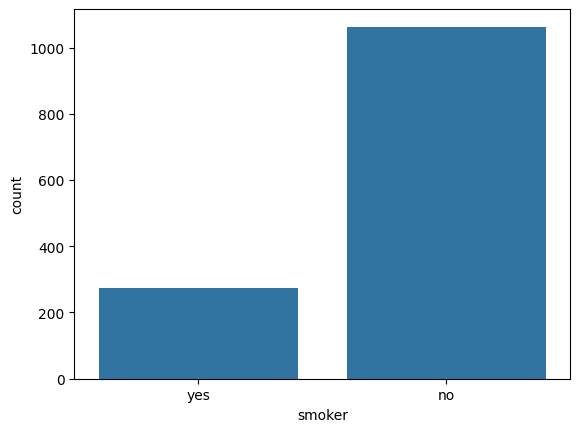

In [14]:
sns.countplot(x = df['smoker'])

<Axes: xlabel='region', ylabel='count'>

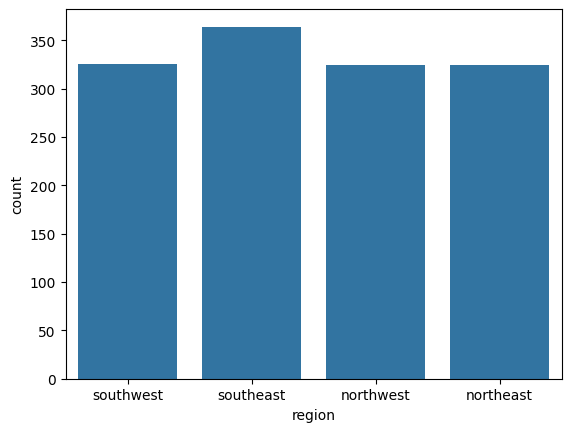

In [15]:
sns.countplot(x = df['region'])

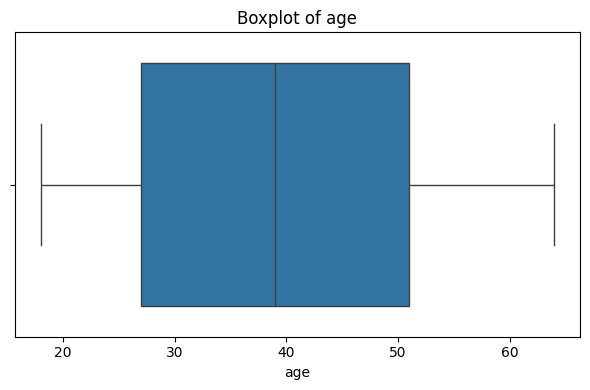

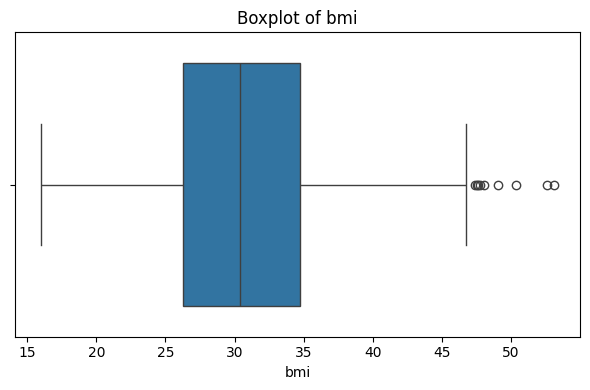

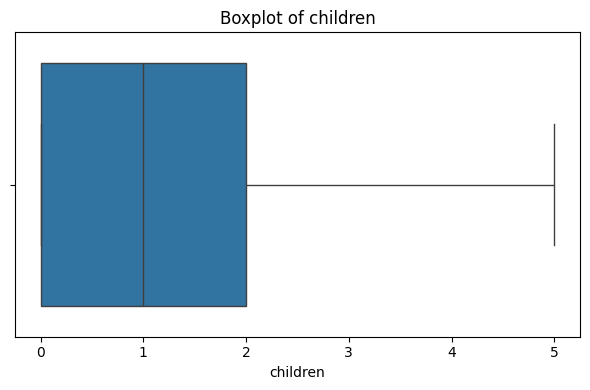

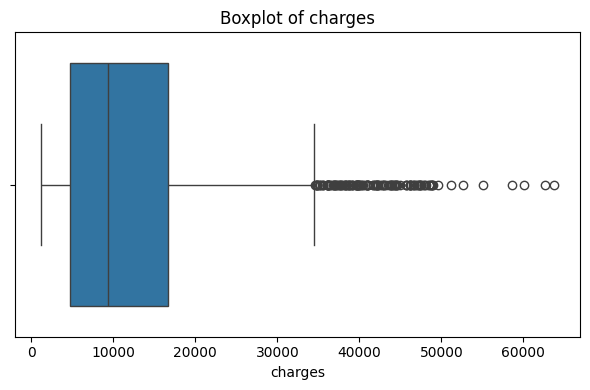

In [16]:
for col in numerical_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  plt.tight_layout()
  plt.show()

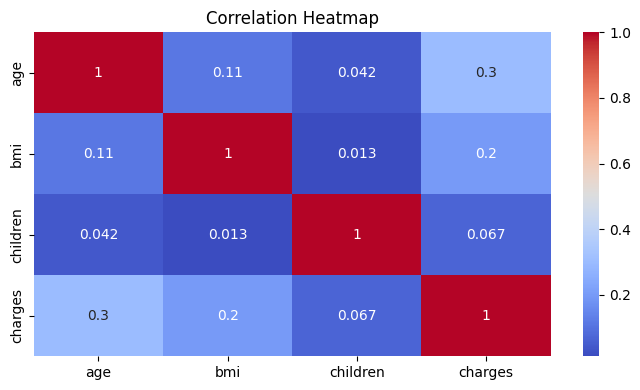

In [17]:
plt.figure(figsize=(7,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#***Data Preprocessing And Data Cleaning***

In [18]:
df_cleaned = df.copy()

In [19]:
df_cleaned.shape

(1337, 7)

In [20]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [21]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [22]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no':0,'yes':1})

In [23]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [24]:
df_cleaned.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [25]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [26]:
# One-Hot Encoding
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'])

In [27]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [28]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


#***Feature Engineering And Extraction***

<Axes: xlabel='bmi', ylabel='Count'>

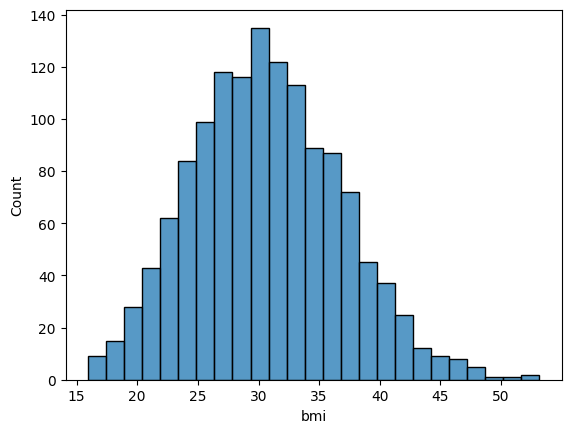

In [29]:
sns.histplot(df_cleaned['bmi'])

In [30]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [31]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,1,0


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x = df_cleaned.drop('charges',axis=1)
y = df_cleaned['charges']

In [34]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'Support Vector Regressor': SVR()
}

In [38]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,root_mean_squared_error

In [39]:
results = []
for name, model in models.items():
  model.fit(x_train_scaled,y_train)
  y_pred = model.predict(x_test_scaled)
  r2 = r2_score(y_test,y_pred)
  mse = mean_squared_error(y_test,y_pred)
  mae = mean_absolute_error(y_test,y_pred)
  rmse = root_mean_squared_error(y_test,y_pred)
  results.append({
      'model':name,
      'R2 Score':round(r2, 4),
      'Mean Squared Error':round(mse, 4),
      'Mean Absolute Error':round(mae, 4),
      'Root Mean Squared Error':round(rmse, 4)
  })

In [40]:
results

[{'model': 'Linear Regression',
  'R2 Score': 0.8027,
  'Mean Squared Error': 36250556.725,
  'Mean Absolute Error': 4340.6129,
  'Root Mean Squared Error': 6020.8435},
 {'model': 'K-Nearest Neighbors Regressor',
  'R2 Score': 0.8659,
  'Mean Squared Error': 24632656.1807,
  'Mean Absolute Error': 3136.5731,
  'Root Mean Squared Error': 4963.1297},
 {'model': 'Decision Tree Regressor',
  'R2 Score': 0.7877,
  'Mean Squared Error': 39020088.1785,
  'Mean Absolute Error': 2838.0706,
  'Root Mean Squared Error': 6246.6061},
 {'model': 'Random Forest Regressor',
  'R2 Score': 0.8837,
  'Mean Squared Error': 21364590.2052,
  'Mean Absolute Error': 2559.5497,
  'Root Mean Squared Error': 4622.1846},
 {'model': 'Gradient Boosting Regressor',
  'R2 Score': 0.903,
  'Mean Squared Error': 17819820.9451,
  'Mean Absolute Error': 2499.215,
  'Root Mean Squared Error': 4221.353},
 {'model': 'Support Vector Regressor',
  'R2 Score': -0.1322,
  'Mean Squared Error': 208050838.5799,
  'Mean Absolute E

In [41]:
import joblib
joblib.dump(models['Gradient Boosting Regressor'],'Gradient_boosting_regressor.pkl' )
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']